In [2]:
from util.stream import Stream, transform_stream
from util.drift_generator import DriftGenerator
import os
import yaml

ModuleNotFoundError: No module named 'util'

### Creating Drifts based on ECG

MBA_ECG801_data
MBA_ECG803_data
MBA_ECG805_data
MBA_ECG806_data


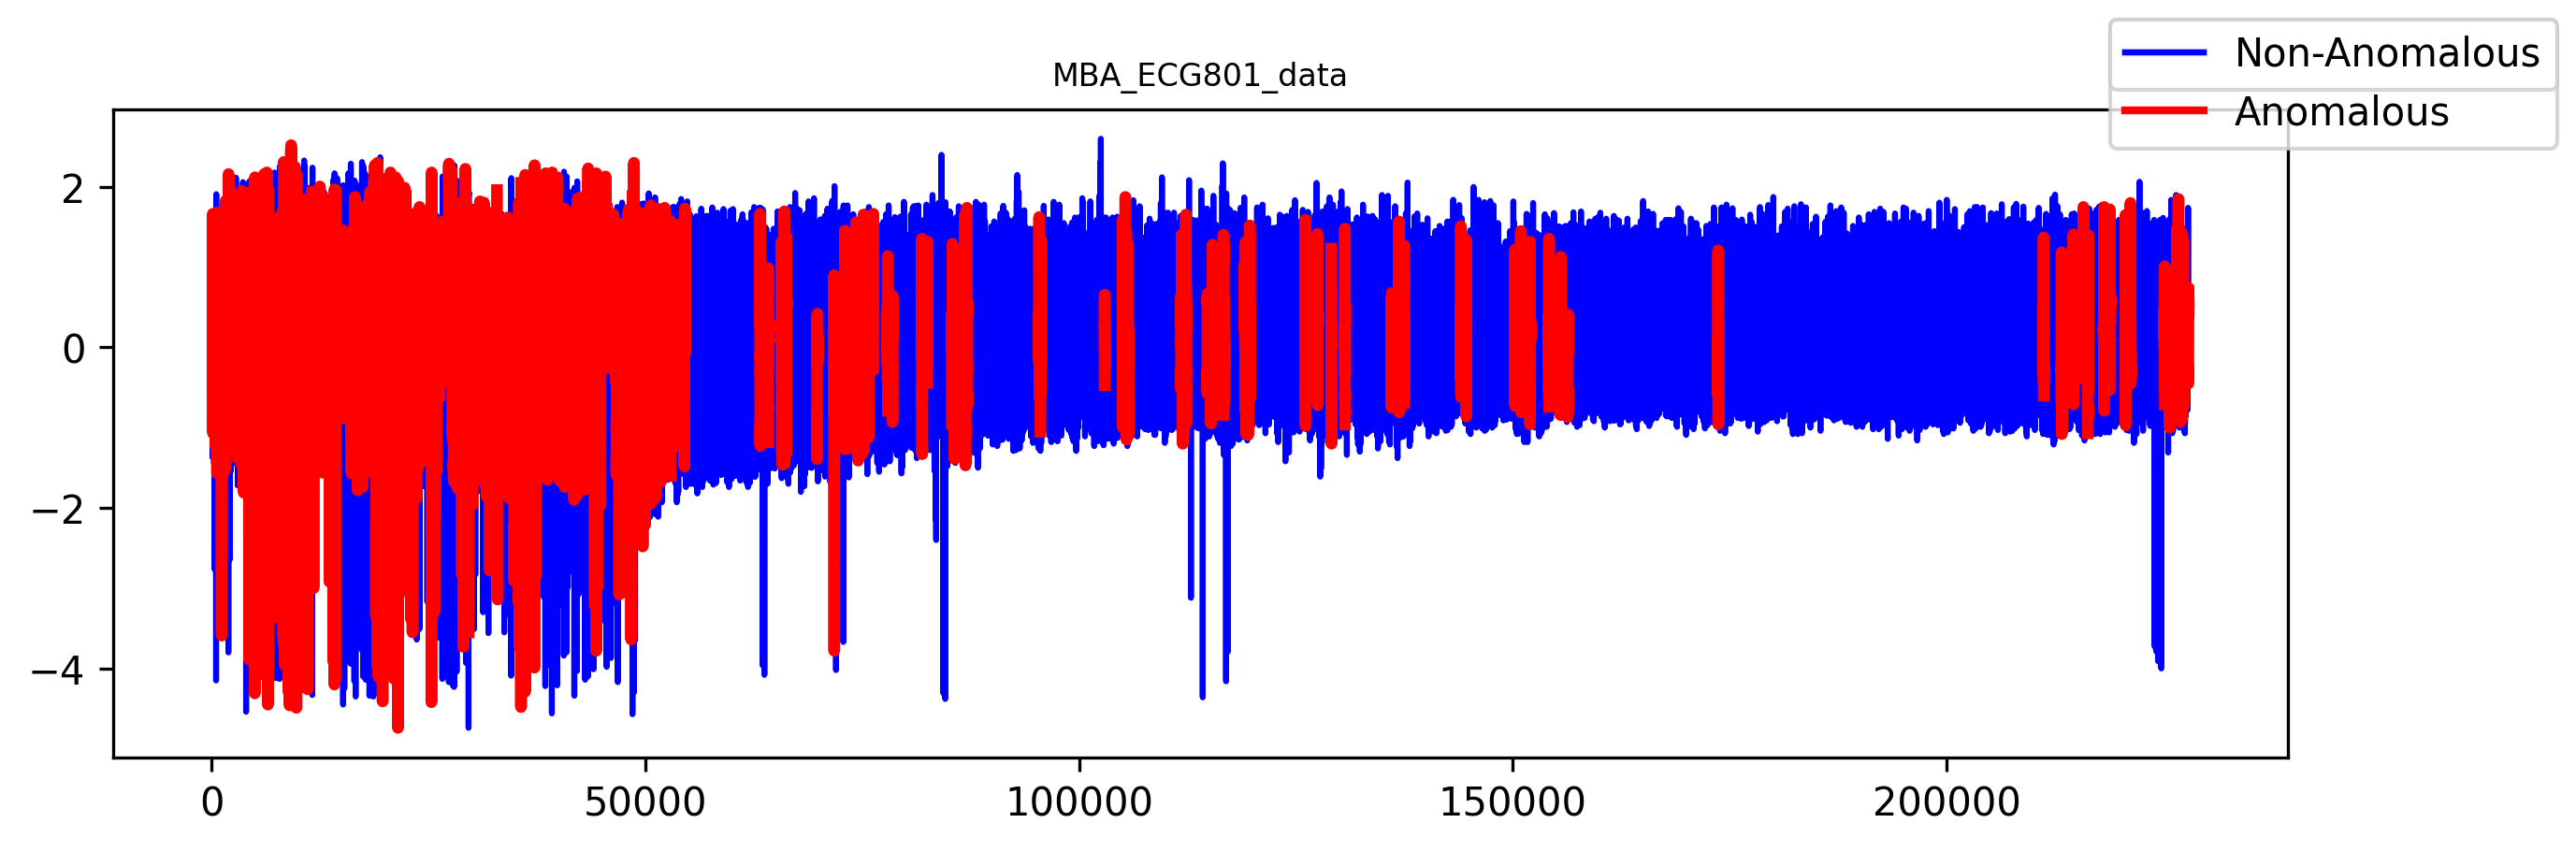

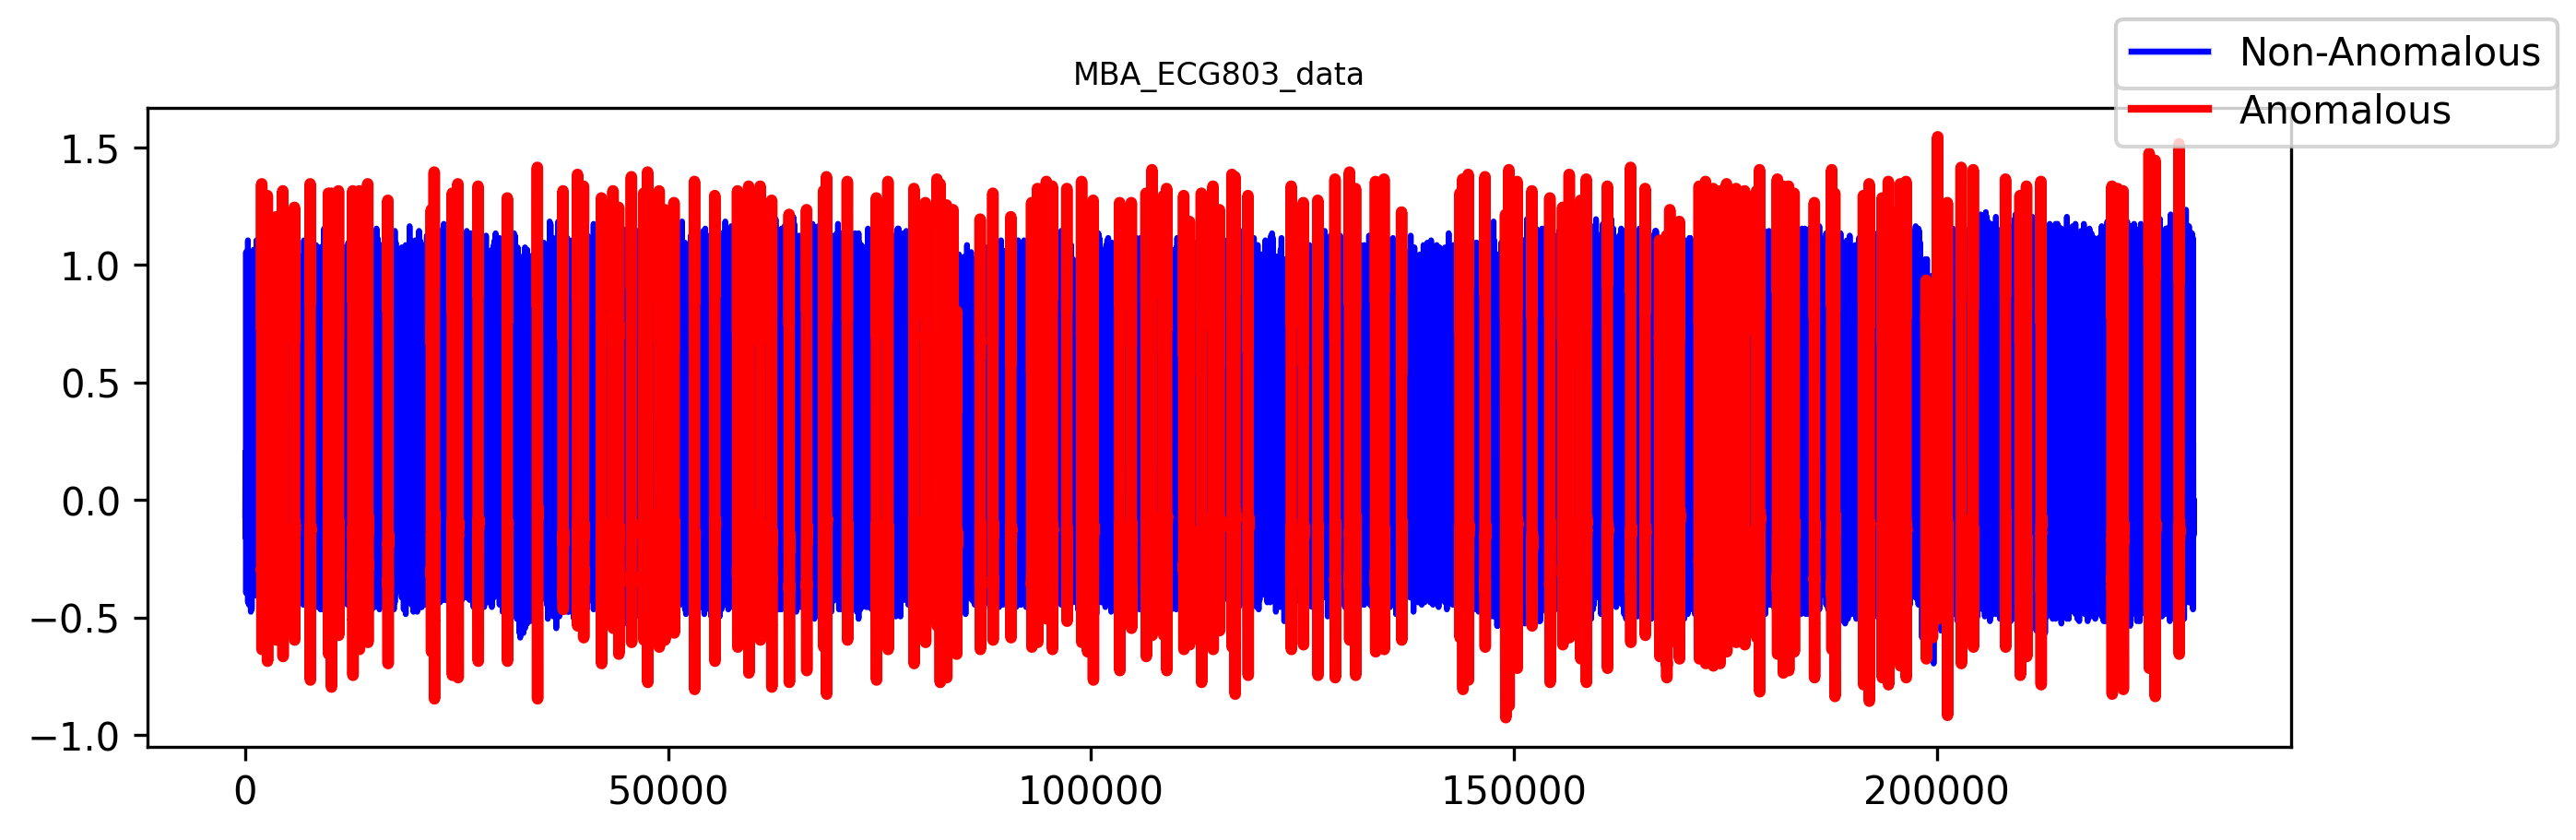

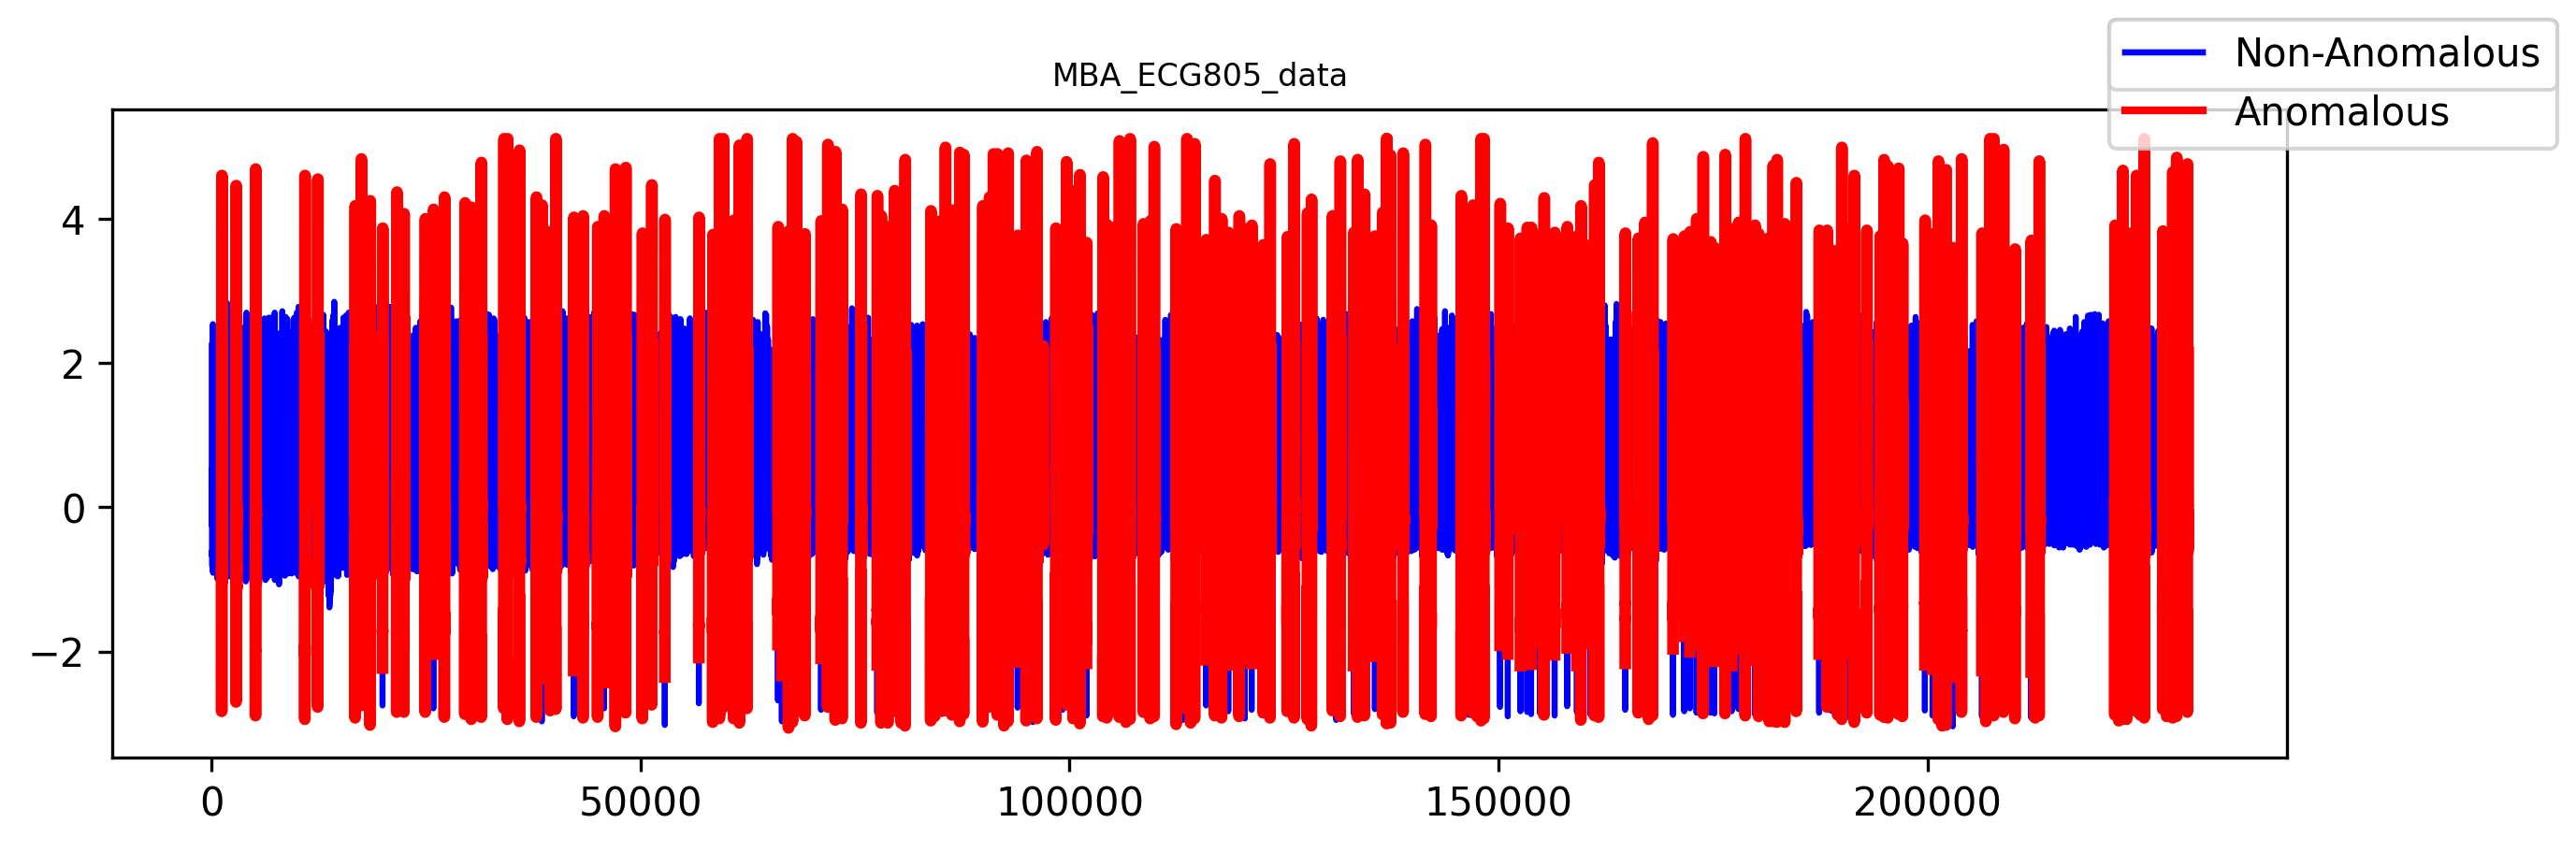

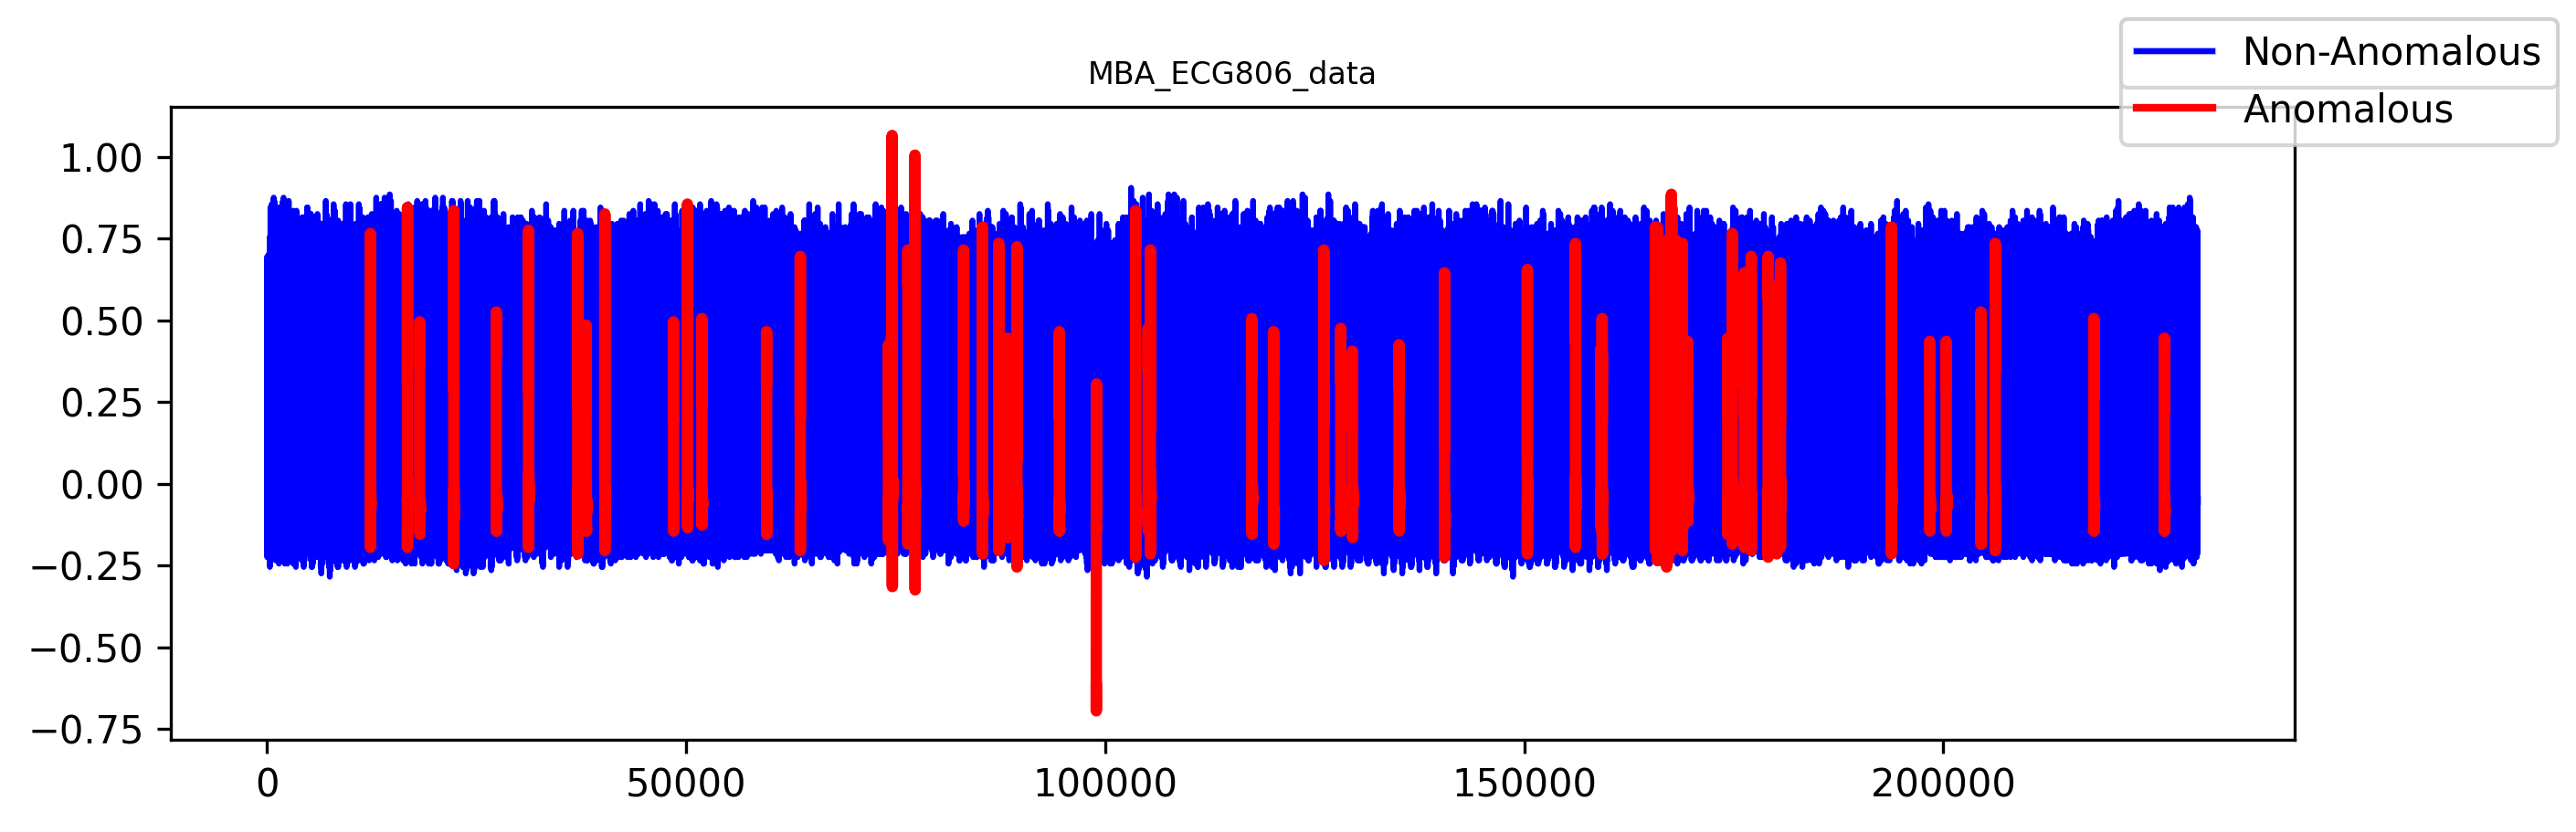

In [4]:
# Parse source filepaths from config (.yaml) file
with open('ECG_test.yaml') as f:
    config_param = yaml.load(f, Loader=yaml.FullLoader)

# source_dir = os.path.abspath(config_param['source_dir'])

selected_files = config_param['source_files']
dir = config_param['source_dir']
ECGStreams = []
for i, file in enumerate(selected_files):
    ECGStreams.append(Stream(f"{dir}/{file}"))
    ECGStreams[i].plot()
    # plt.savefig(f'temp{i}.png')
    print(ECGStreams[i].filename)


In [1]:
moa_path = config_param['moa_path']
source_streams = ECGStreams
drift_dir = os.getcwd()+ config_param['drift_dir']
g = DriftGenerator(dir, drift_dir, moa_path, selected_streams=source_streams)

length = ECGStreams[0].length
dataset = 'ECGTest'

n_drift = config_param['drift_params']['n_drift']
p_drift = config_param['drift_params']['p_drift']
p_before = config_param['drift_params']['p_before']
sub_dir = config_param['drift_params']['sub_dir']

for n_d in n_drift:
    ds = g.run_generate_grad_stream_moa(
        length=length,
        p_drift = p_drift[4],
        n_drift = n_d,
        p_before = p_before,
        sub_dir=sub_dir,
        dataset = dataset,
        mode=0        
    )

    ds.plot_drift()

NameError: name 'config_param' is not defined

In [ ]:
for p_d in p_drift:
    ds = g.run_generate_grad_stream_moa(
        length=length,
        p_drift = p_d,
        n_drift = n_drift[4],
        p_before = p_before,
        sub_dir=sub_dir,
        dataset = dataset,
        mode=0        
    )

    ds.plot_drift()